# Grover's Algorithm

 ## In this notebook, we explore how Quantum Computing finds a "needle in a haystack" not by checking every straw, but by using Interference to tilt the probability toward the right answer.

In [429]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram, plot_bloch_multivector

In [422]:
def oracle(target_str):
    """Flips the phase of the target bitstring."""
    n = len(target_str)
    qc = QuantumCircuit(n)
    # This logic marks the specific state by flipping its sign
    for i, bit in enumerate(reversed(target_str)):
        if bit == '0': qc.x(i)
    qc.h(n-1)
    qc.mcx(list(range(n-1)), n-1) # Multi-controlled X
    qc.h(n-1)
    for i, bit in enumerate(reversed(target_str)):
        if bit == '0': qc.x(i)
    return qc.to_gate(label=f" Oracle ({target_str}) ")

def diffuser(n):
    qc = QuantumCircuit(n, name="Diffuser")
    
    # 1. Layer of Hadamards
    qc.h(range(n))
    qc.barrier()
    
    # 2. Layer of X-gates
    qc.x(range(n))
    qc.barrier()
    
    # 3. Multi-Controlled Z logic
    # This marks the |0000> state specifically
    qc.h(n-1)
    qc.mcx(list(range(n-1)), n-1)
    qc.h(n-1)
    qc.barrier()
    
    # 4. Undo the X-gates and H-gates
    qc.x(range(n))
    qc.barrier()
    qc.h(range(n))
    
    return qc

def plot_amplitudes(state, title="Statevector Amplitudes"):
    # --- ADD THIS LINE TO FIX GLOBAL PHASE ---
    # We find the phase of the first element and rotate the entire vector by that negative amount.
    # This ensures the first element (usually 0000) starts positive.
    standardized_data = state.data * np.exp(-1j * np.angle(state.data[0]))
    amplitudes = standardized_data.real 
    # -----------------------------------------
    
    avg_amp = np.mean(amplitudes)
    labels = [format(i, '04b') for i in range(16)]
    
    plt.figure(figsize=(12, 5))
    # We color based on the target string now to make it even clearer
    colors = ['#648FFF' if a >= 0 else '#DC267C' for a in amplitudes]
    
    plt.bar(labels, amplitudes, color=colors)
    plt.axhline(avg_amp, color='orange', linestyle='--', label=f'Average: {avg_amp:.3f}')
    plt.xticks(rotation=45)
    plt.axhline(0, color='black', linewidth=0.8)
    plt.title(title)
    plt.ylabel("Amplitude")
    plt.legend()
    plt.show()

## Step 1 of our algorithm is to prepare the equal superposition state of our system.

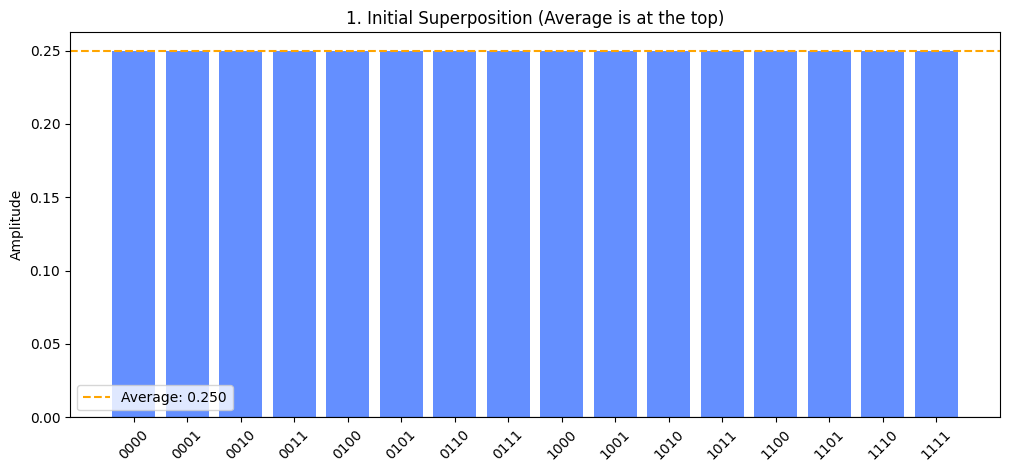

In [423]:
# --- DEMONSTRATION ---
n = 4
target = "0101"
# Start the circuit
qc = QuantumCircuit(n)
qc.h(range(n))

# Visualize the starting point
state = Statevector.from_instruction(qc)
plot_amplitudes(state, title="1. Initial Superposition (Average is at the top)")

## Now we put our state through some oracle that will do the following:

### 1. For every component of our state that is not the solution it will do nothing
### 2. For the component of our state that represents the solution, it will flip the sign of it's coefficient

### So for example:

* $|0000\rangle \rightarrow +|0000\rangle$
* $|0001\rangle \rightarrow +|0001\rangle$
* $|0010\rangle \rightarrow +|0010\rangle$
* $|0011\rangle \rightarrow +|0011\rangle$
* $|0100\rangle \rightarrow +|0100\rangle$
* $|0101\rangle \rightarrow -|0101\rangle$ **(Solution)**
* $|0110\rangle \rightarrow +|0110\rangle$
* $|0111\rangle \rightarrow +|0111\rangle$
* $|1000\rangle \rightarrow +|1000\rangle$
* $|1001\rangle \rightarrow +|1001\rangle$
* $|1010\rangle \rightarrow +|1010\rangle$
* $|1011\rangle \rightarrow +|1011\rangle$
* $|1100\rangle \rightarrow +|1100\rangle$
* $|1101\rangle \rightarrow +|1101\rangle$
* $|1110\rangle \rightarrow +|1110\rangle$
* $|1111\rangle \rightarrow +|1111\rangle$

### This step probably looks an awful lot like cheating. Don't worry, it will be explained in more detail at the end of the notebook. Just accept for now that this is something we can do.

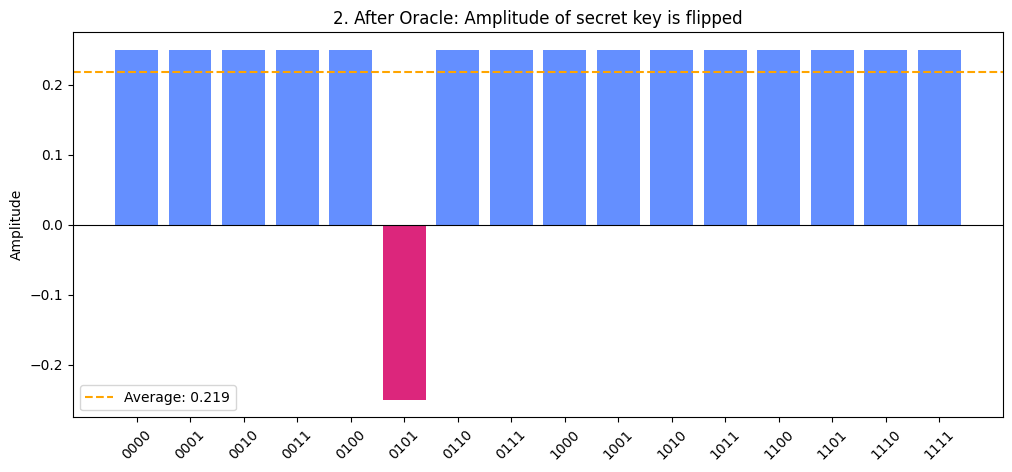

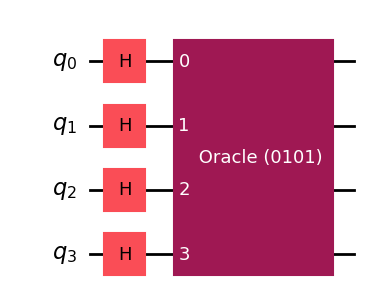

In [424]:
# Add the Oracle logic (Logic, not a black box)
qc.compose(oracle(target), inplace=True)

# Visualize the 'Marking'
state = Statevector.from_instruction(qc)
plot_amplitudes(state, title="2. After Oracle: Amplitude of secret key is flipped")
qc.draw("mpl")

### Next we put the resulting state through the Diffuser.

### The Diffuser (defined as $D = 2|s\rangle\langle s| - I$) calculates the average of all amplitudes and reflects every state across that average. It acts as a "contrast enhancer," shrinking the wrong answers and growing the right one.

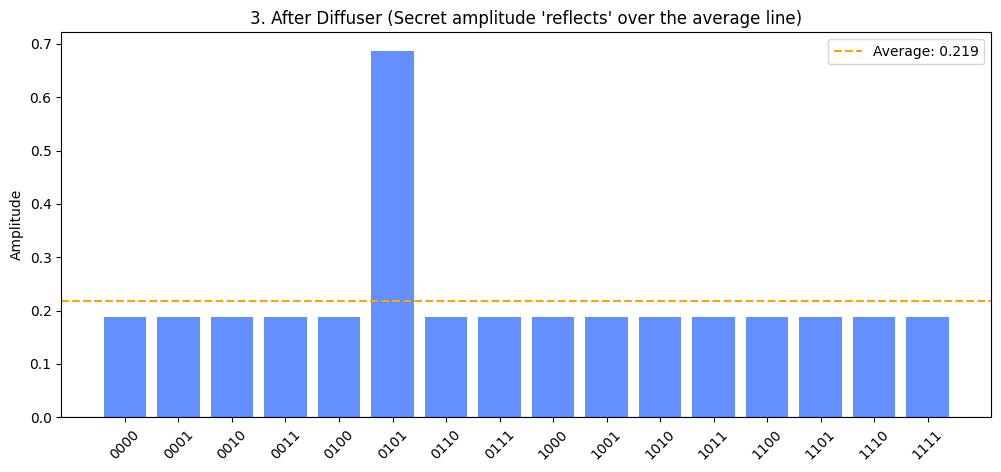

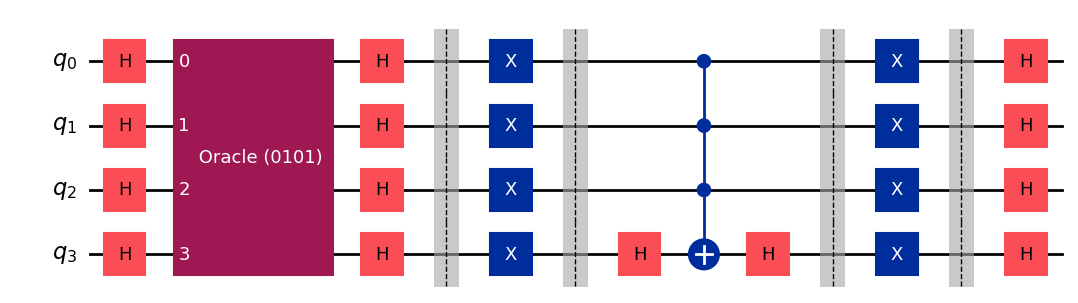

In [425]:
qc.compose(diffuser(n), inplace=True)
# Visualize the 'Amplification'
state = Statevector.from_instruction(qc)
plot_amplitudes(state, title="3. After Diffuser (Secret amplitude 'reflects' over the average line)")
qc.draw("mpl")

## And now we simply repeat

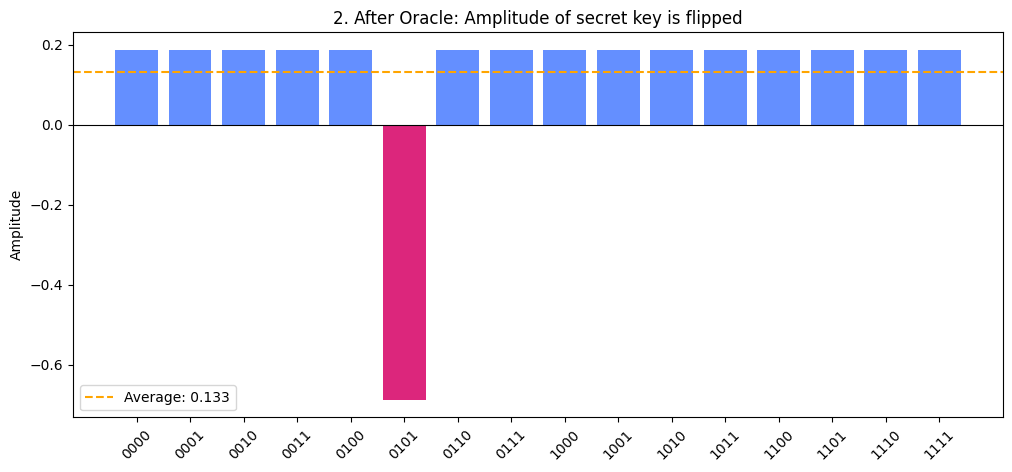

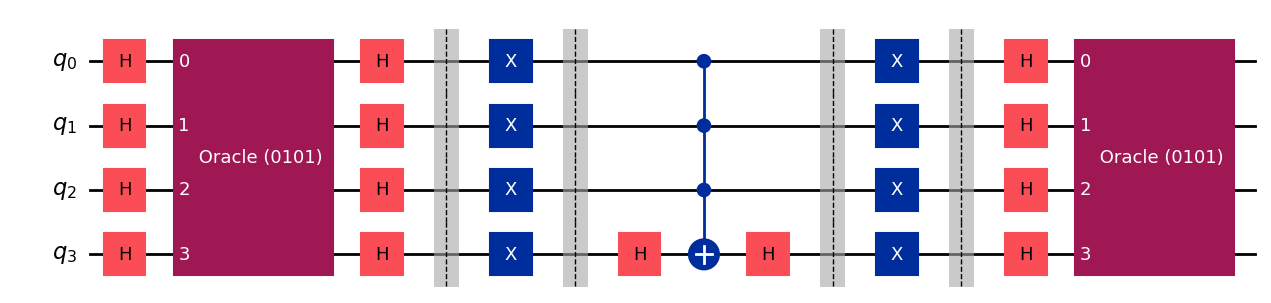

In [426]:
# Add the Oracle logic (Logic, not a black box)
qc.compose(oracle(target), inplace=True)

# Visualize the 'Marking'
state = Statevector.from_instruction(qc)
plot_amplitudes(state, title="2. After Oracle: Amplitude of secret key is flipped")
qc.draw("mpl")

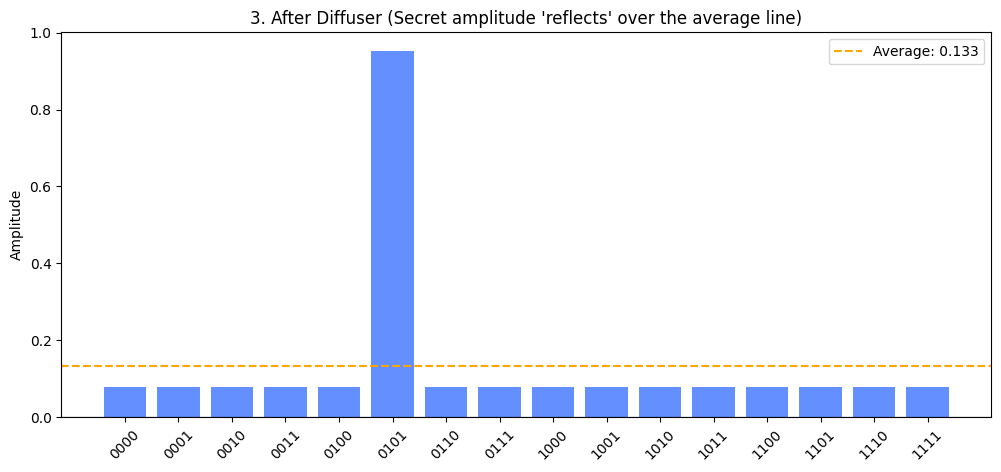

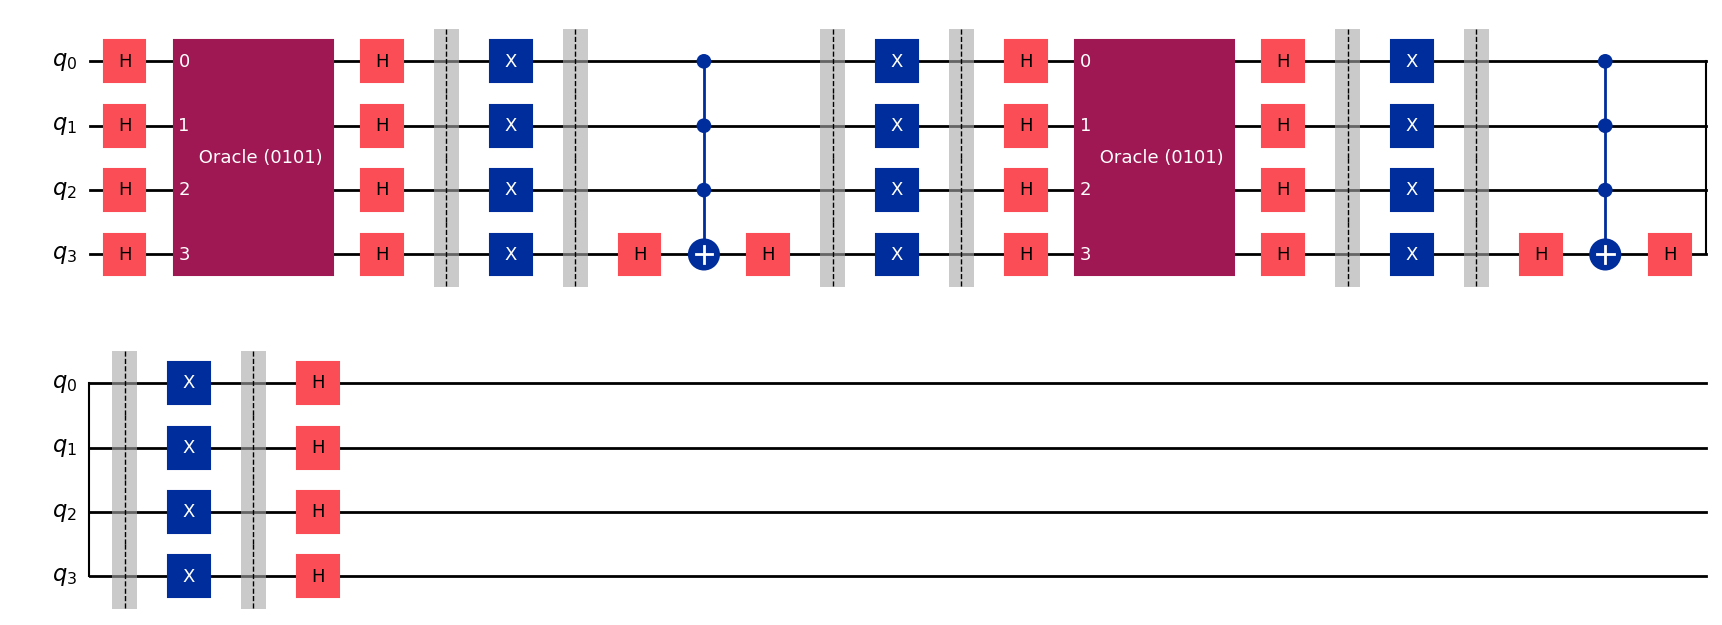

In [427]:
qc.compose(diffuser(n), inplace=True)
# Visualize the 'Amplification'
state = Statevector.from_instruction(qc)
plot_amplitudes(state, title="3. After Diffuser (Secret amplitude 'reflects' over the average line)")
qc.draw("mpl")

---
## A slightly different visualisation

In [445]:
def plot_grover_2d(state, target_str, title):
    n = len(target_str)
    N = 2**n
    winner_vec = Statevector.from_label(target_str)
    
    # 1. Define basis vectors
    all_states_sum = np.ones(N) / np.sqrt(N)
    projection_on_winner = np.dot(winner_vec.data.conj(), all_states_sum)
    s_prime_data = all_states_sum - projection_on_winner * winner_vec.data
    s_prime_vec = s_prime_data / np.linalg.norm(s_prime_data)
    
    # 2. Phase Correction (Standardize to s_prime)
    phase_check = np.dot(s_prime_vec.conj(), state.data)
    standardized_state = state.data * np.exp(-1j * np.angle(phase_check)) if np.abs(phase_check) > 1e-10 else state.data

    # 3. Calculate coordinates
    x = np.real(np.dot(s_prime_vec.conj(), standardized_state))
    y = np.real(np.dot(winner_vec.data.conj(), standardized_state))
    
    # 4. Calculate the 'Mirror Line' (The |s> state)
    # The average state |s> in this 2D plane
    s_x = np.sqrt((N-1)/N)
    s_y = np.sqrt(1/N)
    
    # --- Plotting ---
    plt.figure(figsize=(5,7))
    
    # Plot the Mirror Line (The Average State |s>)
    plt.plot([0, s_x*1.1], [0, s_y*1.1], color='orange', linestyle='--', label='Mirror Line (|s>)')
    
    # Plot the Current State Vector
    plt.quiver(0, 0, x, y, angles='xy', scale_units='xy', scale=1, color='#648FFF', width=0.01, label='Current State')
    
    # Background helpers
    theta = np.linspace(-np.pi/2, np.pi/2, 100)
    plt.plot(np.cos(theta), np.sin(theta), color='gray', linestyle=':', alpha=0.3)
    
    plt.xlim(-0.1, 1.1); plt.ylim(-1.1, 1.1)
    plt.axhline(0, color='black', lw=1); plt.axvline(0, color='black', lw=1)
    plt.xlabel("All Other States (|s'>)"); plt.ylabel("The Solution (|w>)")
    plt.title(f"{title}")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.2)
    plt.show()

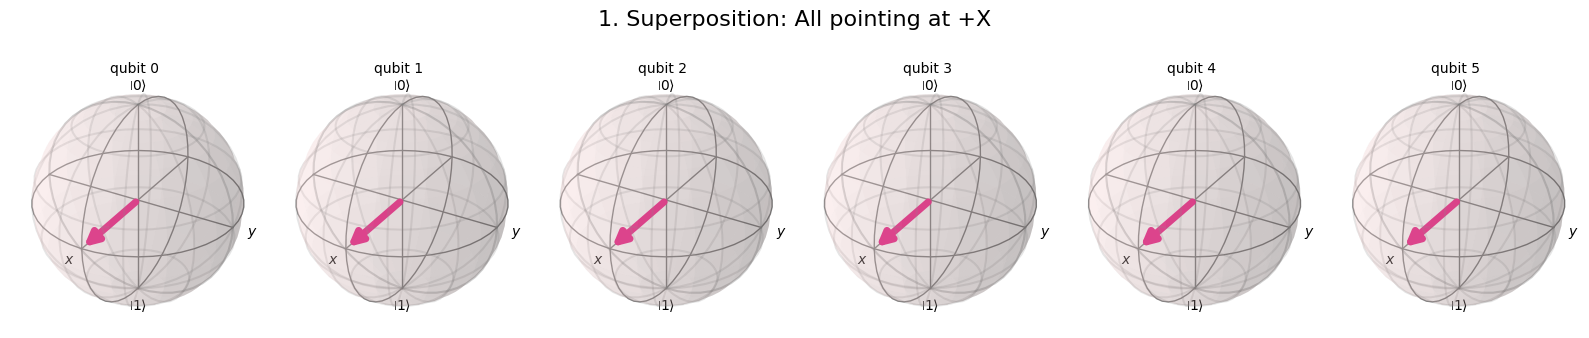

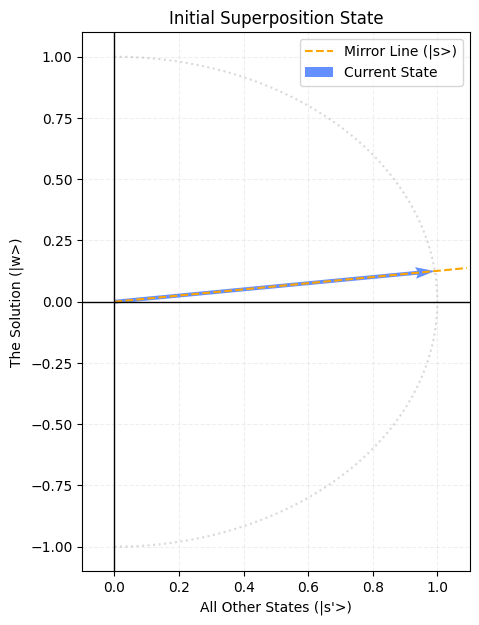

In [460]:
from qiskit.visualization import plot_bloch_multivector

# Setup 4 qubits for target 0101
n = 6
target = "010101"
qc_bloch = QuantumCircuit(n)

# 1. Start: Equal Superposition
qc_bloch.h(range(n))
state = Statevector.from_instruction(qc_bloch)
display(plot_bloch_multivector(state, title="1. Superposition: All pointing at +X"))
plot_grover_2d(state, target_str="010101", title="Initial Superposition State")

### We can visualise our high dimensional vector by putting our solution axis in the y-axis, and squeezing every other axis into the x-axis. 

### This means when we prepare our initial superposition vector it points slightly in the y-direction, and mostly in x-direction.

### Then when we apply the oracle:

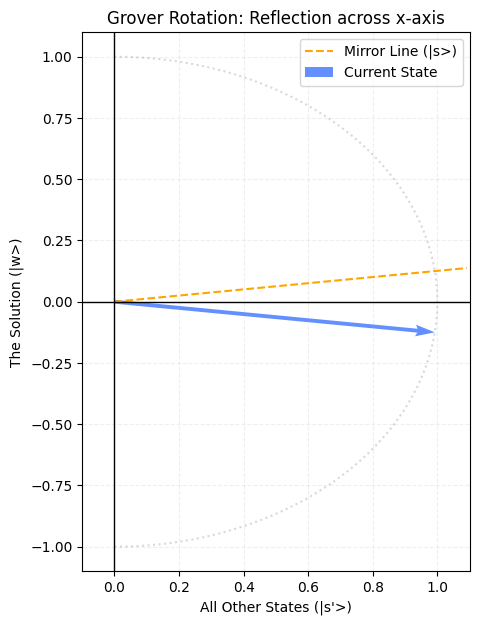

In [461]:
qc_bloch.append(oracle(target), range(n))
state = Statevector.from_instruction(qc_bloch)
plot_grover_2d(state, target_str="010101", title="Grover Rotation: Reflection across x-axis")

### ... the y component gains a minus sign so it flips in the x-axis

### Next we apply the diffuser. This has the effect of flipping in the axis defined by the superposition statevector itself.

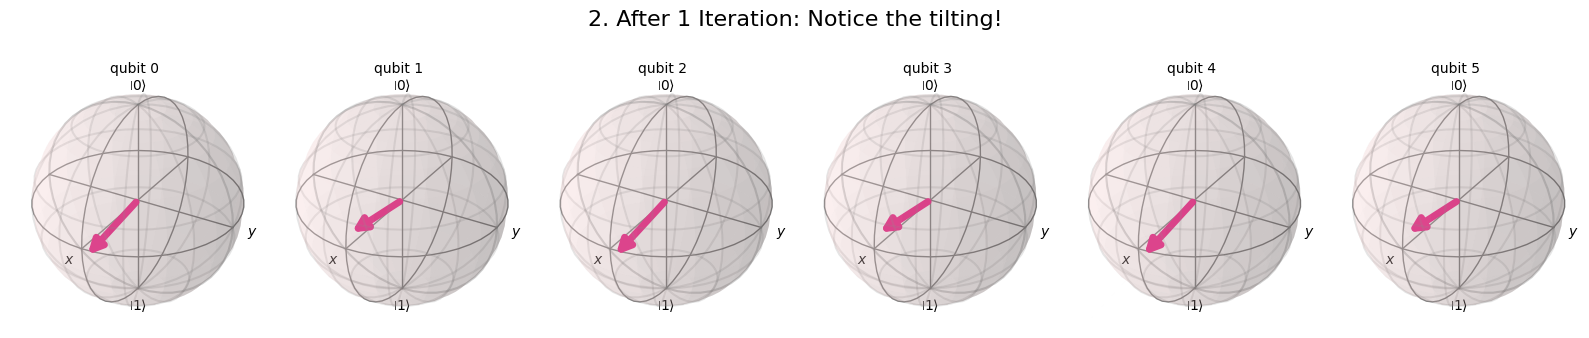

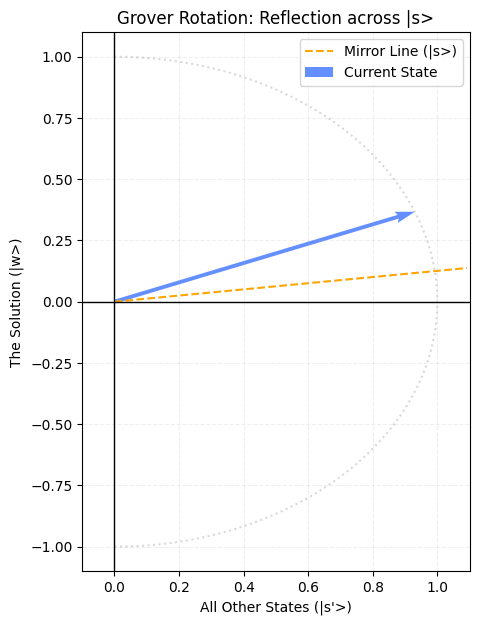

In [462]:
qc_bloch.append(diffuser(n), range(n))
state = Statevector.from_instruction(qc_bloch)
display(plot_bloch_multivector(state, title="2. After 1 Iteration: Notice the tilting!"))
plot_grover_2d(state, target_str="010101", title="Grover Rotation: Reflection across |s>")

### And then we repeat:

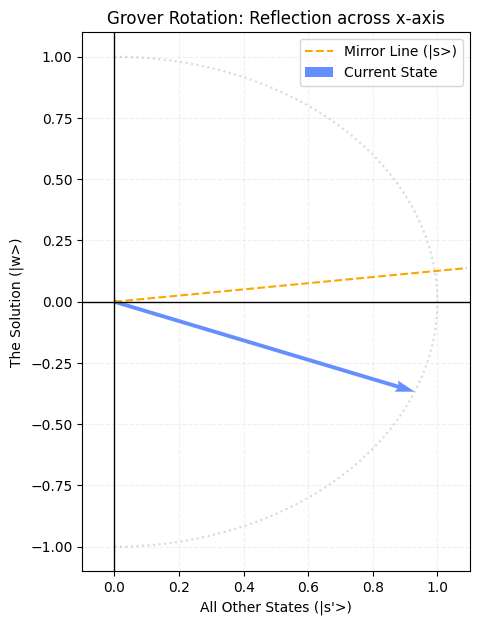

In [463]:
qc_bloch.append(oracle(target), range(n))
state = Statevector.from_instruction(qc_bloch)
plot_grover_2d(state, target_str="010101", title="Grover Rotation: Reflection across x-axis")

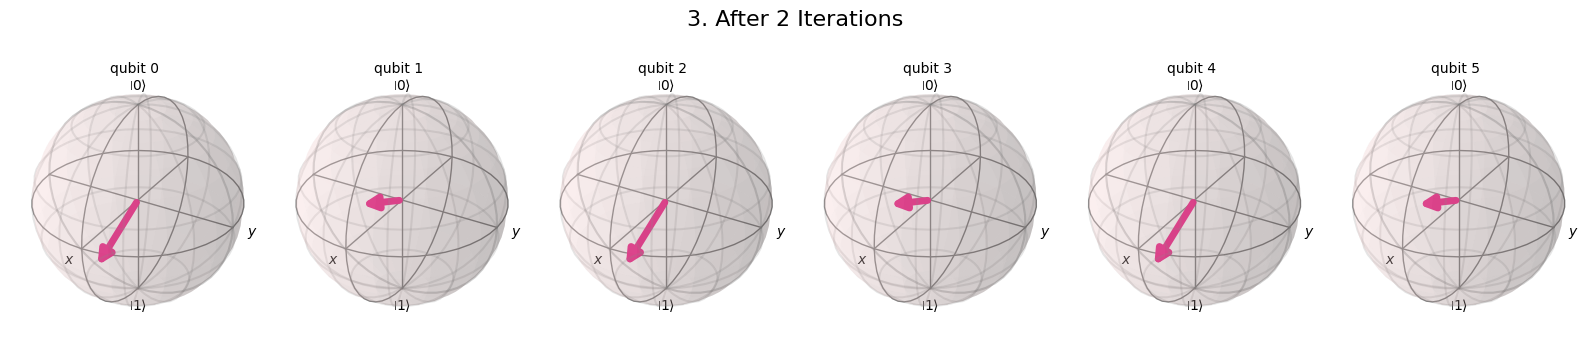

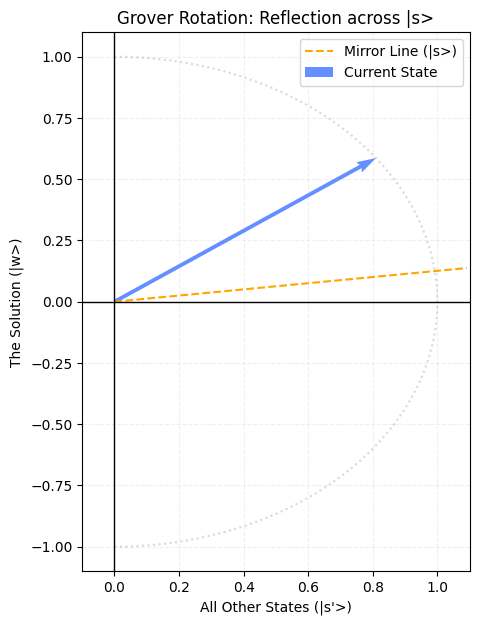

In [464]:
qc_bloch.append(diffuser(n), range(n))
state = Statevector.from_instruction(qc_bloch)
display(plot_bloch_multivector(state, title="3. After 2 Iterations"))
plot_grover_2d(state, target_str="010101", title="Grover Rotation: Reflection across |s>")

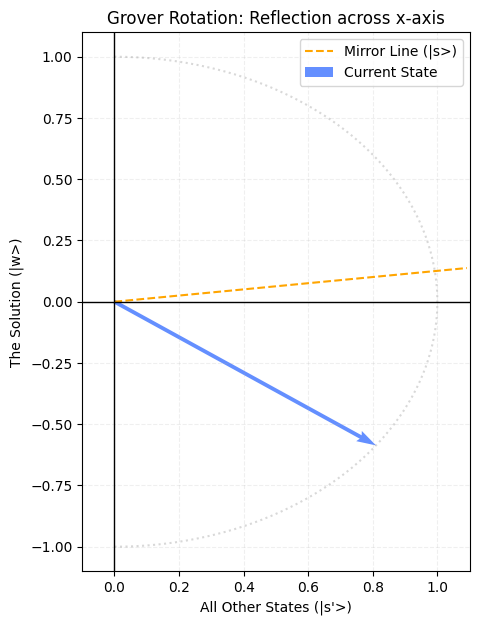

In [465]:
qc_bloch.append(oracle(target), range(n))
state = Statevector.from_instruction(qc_bloch)
plot_grover_2d(state, target_str="010101", title="Grover Rotation: Reflection across x-axis")

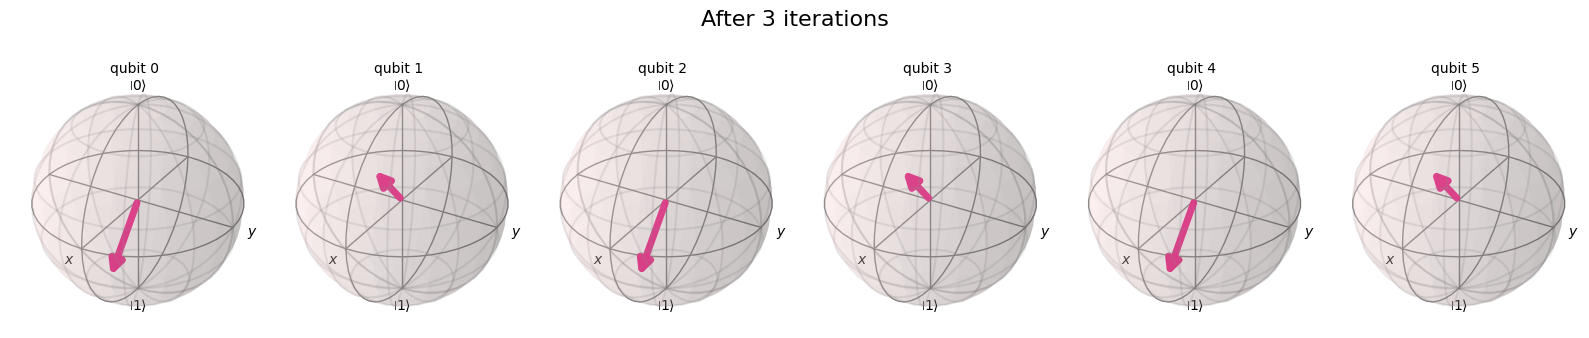

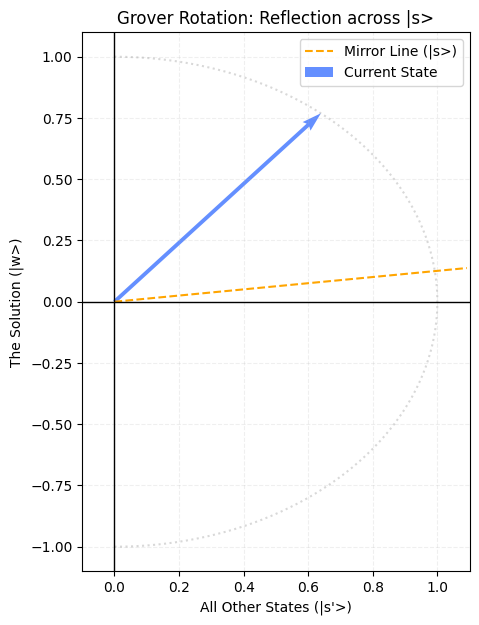

In [466]:
qc_bloch.append(diffuser(n), range(n))
state = Statevector.from_instruction(qc_bloch)
display(plot_bloch_multivector(state, title="After 3 iterations"))
plot_grover_2d(state, target_str="010101", title="Grover Rotation: Reflection across |s>")

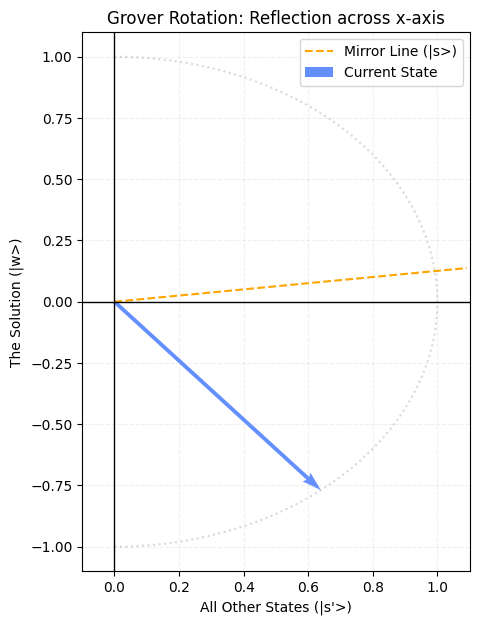

In [467]:
qc_bloch.append(oracle(target), range(n))
state = Statevector.from_instruction(qc_bloch)
plot_grover_2d(state, target_str="010101", title="Grover Rotation: Reflection across x-axis")

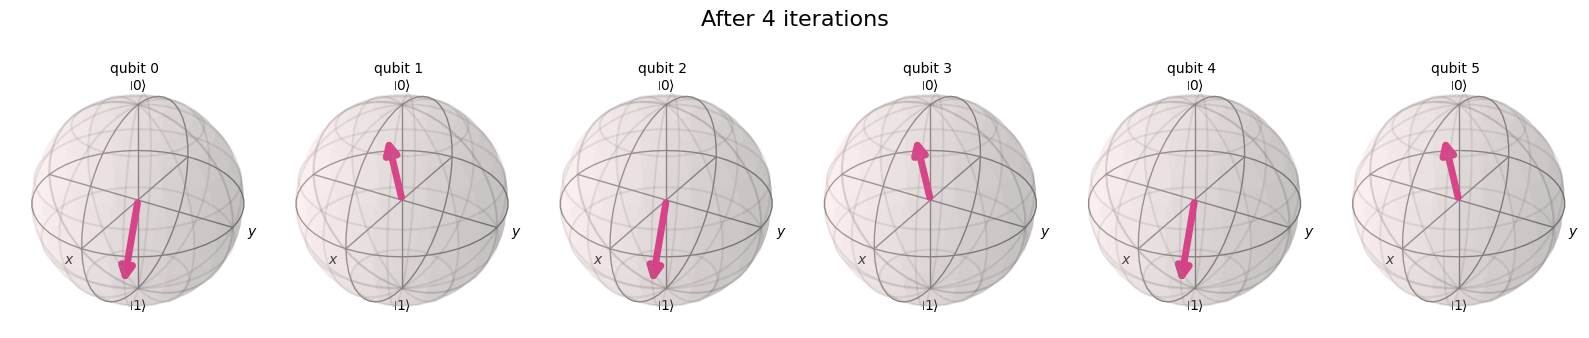

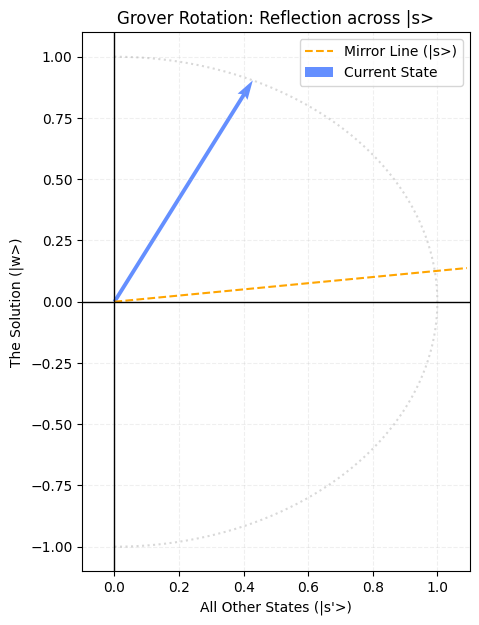

In [468]:
qc_bloch.append(diffuser(n), range(n))
state = Statevector.from_instruction(qc_bloch)
display(plot_bloch_multivector(state, title="After 4 iterations"))
plot_grover_2d(state, target_str="010101", title="Grover Rotation: Reflection across |s>")

### If we apply this procedure approximately $\sqrt{N}$ times (where $N=2^n$ ie the number of possible states), then our statevector will point almost entirely in the direction of the solution. Actually because we are literally traversing a quarter length of a unit square it takes ~$\frac{\pi}{4} \sqrt{N}$ operations.

### If you tried to break a similarly hard problem classically (for example SHA256) where you can essentially do no better than just guess a solution, it will take on average $N/2$ operations.

---
## The oracle explanation

#### If you are sceptical about this magic oracle that flips the sign of the solution, I don't blame you. We just defined an algorithm where one of the key steps was to somehow mark the solution. If we could do that then why do we need an algorithm at all? 

#### The answer lies in the distinction between knowing the solution and knowing the rules. In a practical scenario, the Oracle isn't a hard-coded 'search for $x$'; it is a logical verification circuit. 

#### Think of a complex Sudoku puzzle: you don't know the solution, but you can easily build a classical circuit that checks if a grid follows the rules (no repeats in rows or columns). The Oracle is simply that 'rule-checker' translated into quantum gates.

#### By passing a total superposition of all possible grids through this checker, the Oracle uses 'Phase Kickback' to flip the sign of only the specific states that satisfy your logic. We haven't 'cheated' by providing the answer; we have provided the criteria, and the quantum interference pattern does the work of 'solving' for the inputs that meet them. In essence, the Oracle identifies the needle by the logical constraints, allowing the Diffuser to then magnify that needle until it’s the only thing we see.

#### For a better explanation see this video https://www.youtube.com/watch?v=Dlsa9EBKDGI&t=790s